# TP 3 — Pipeline complet : solution commentée

Solution complète du [TP 3](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
from skimage import data, filters, measure, morphology
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

coins = data.coins()

## Exercice 1 — Segmentation

/var/folders/8m/l_690lqs2v51h4cv_vz7lllr0000gn/T/ipykernel_6074/2171717773.py:3: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = morphology.binary_opening(mask, morphology.disk(2))
/var/folders/8m/l_690lqs2v51h4cv_vz7lllr0000gn/T/ipykernel_6074/2171717773.py:4: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = morphology.binary_closing(mask, morphology.disk(5))


(np.float64(-0.5), np.float64(383.5), np.float64(302.5), np.float64(-0.5))

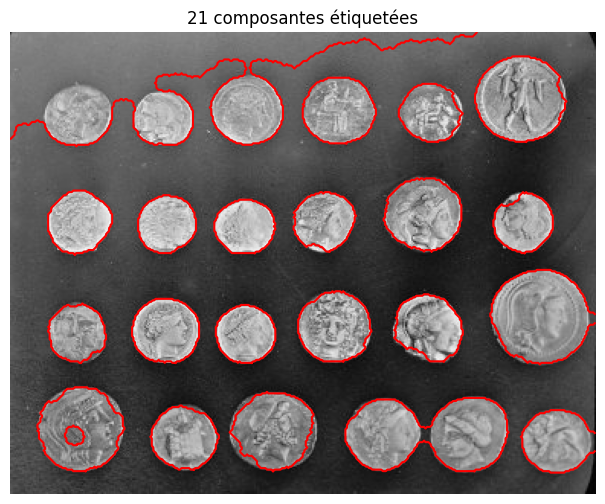

In [2]:
t = filters.threshold_otsu(coins)
mask = coins > t
mask = morphology.binary_opening(mask, morphology.disk(2))
mask = morphology.binary_closing(mask, morphology.disk(5))
labels = measure.label(mask)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(coins, cmap="gray")
for contour in measure.find_contours(mask, 0.5):
    ax.plot(contour[:, 1], contour[:, 0], "r", linewidth=1.5)
ax.set_title(f"{labels.max()} composantes étiquetées")
ax.axis("off")

## Exercice 2 — Features par objet

In [3]:
props = measure.regionprops(labels, intensity_image=coins)
kept = [p for p in props if p.area >= 200]

feature_names = ["area", "perimeter", "eccentricity", "solidity", "mean_intensity"]
X = np.array([[p.area, p.perimeter, p.eccentricity, p.solidity, p.mean_intensity] for p in kept])
print(f"{len(kept)} pièces, X shape = {X.shape}")

import pandas as pd

pd.DataFrame(X, columns=feature_names).head(10)

21 pièces, X shape = (21, 5)


/var/folders/8m/l_690lqs2v51h4cv_vz7lllr0000gn/T/ipykernel_6074/2511798080.py:5: FutureWarning: `RegionProperties.mean_intensity` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.intensity_mean` instead. 
  X = np.array([[p.area, p.perimeter, p.eccentricity, p.solidity, p.mean_intensity] for p in kept])


,area,perimeter,eccentricity,solidity,mean_intensity
0,11730.0,1026.932070,0.947375,0.672245,137.838875
1,2558.0,191.237590,0.255730,0.968206,156.888585
2,1637.0,150.124892,0.385344,0.980240,157.263897
3,1160.0,129.539105,0.344893,0.955519,153.474138
4,1868.0,164.994949,0.360951,0.971399,159.506959
5,1315.0,133.539105,0.357292,0.977695,189.487452
6,1170.0,132.024387,0.402017,0.954323,170.997436
7,1120.0,128.124892,0.430563,0.949958,171.250000
8,1128.0,123.396970,0.351972,0.974935,190.022163
9,1102.0,122.225397,0.446819,0.980427,193.046279


## Exercice 3 — Clustering en 2 groupes

cluster 0 : 20 pièces
cluster 1 : 1 pièces


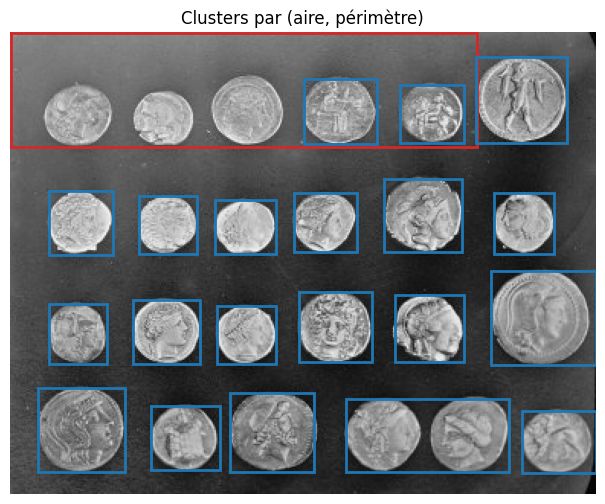

In [4]:
X_kmeans = StandardScaler().fit_transform(X[:, :2])  # area, perimeter
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X_kmeans)
clusters = km.labels_

# Affichage avec bounding boxes colorées par cluster
colors = ["#1f77b4", "#d62728"]
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(coins, cmap="gray")
for p, c in zip(kept, clusters):
    minr, minc, maxr, maxc = p.bbox
    ax.add_patch(
        patches.Rectangle(
            (minc, minr),
            maxc - minc,
            maxr - minr,
            edgecolor=colors[c],
            facecolor="none",
            linewidth=2,
        )
    )
ax.set_title("Clusters par (aire, périmètre)")
ax.axis("off")

for k in range(2):
    print(f"cluster {k} : {(clusters == k).sum()} pièces")

## Exercice 4 — Scatter des features

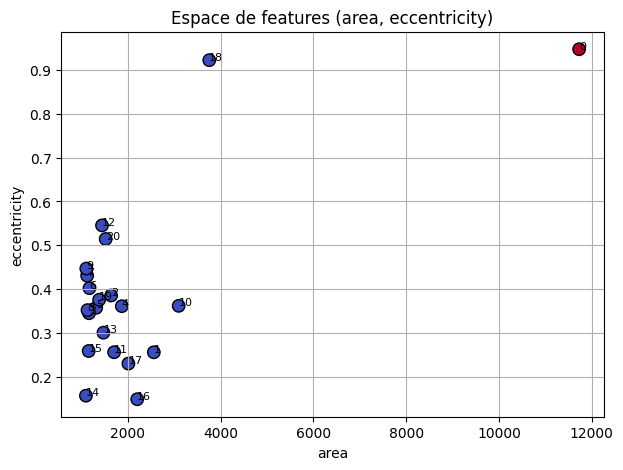

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(X[:, 0], X[:, 2], c=clusters, cmap="coolwarm", s=80, edgecolors="k")
for i, (a, ec) in enumerate(zip(X[:, 0], X[:, 2])):
    ax.text(a, ec, str(i), fontsize=8)
ax.set_xlabel("area")
ax.set_ylabel("eccentricity")
ax.set_title("Espace de features (area, eccentricity)")
ax.grid(True)

**Discussion** : sur `data.coins` les deux groupes se distinguent essentiellement par l'aire. Sur des images plus complexes, on combinera plusieurs features (`solidity` pour distinguer une pièce d'un objet irrégulier, `mean_intensity` pour distinguer une pièce de bronze d'une pièce d'argent...) et on basculera vers un classifieur supervisé entraîné sur quelques exemples annotés.